# EDA of the eSEEd_v2 emotion dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import seaborn as sns



## Prepare dataset
- load
- clean

In [2]:
data_dir = "../../data/processed/eSEEd_v2_processed/"

In [3]:
# load eseed dataset
def load_eseed_dataset(data_dir):
    strat_time = time.time()
    df = pd.DataFrame()
    for csv_file in os.listdir(data_dir):
        if csv_file.endswith(".csv"):
            df_part = pd.read_csv(os.path.join(data_dir, csv_file))
            df = pd.concat([df, df_part], ignore_index=True)
    print(f"Loaded eSEEd dataset in {time.time() - strat_time:.2f} seconds.")
    return df


In [4]:
df = load_eseed_dataset(data_dir)
dfOG = df.copy()  # keep original for comparison

Loaded eSEEd dataset in 11.04 seconds.


In [5]:
subjects = df['subject'].unique()
recordings = df['recording'].unique()
emotion_cols = [col for col in df.columns if "emotion" in col]

## Percentage of NaN rows 


In [6]:
# percentage of nan rows (the same for all columns except timestamp, subject, recording)
df = dfOG.copy()
(df.isna().sum() / len(df) * 100)["x-avg"].round(2)

np.float64(1.32)

In [7]:
print("Checking subjects")
for subject in subjects:
    df_subj = df[df['subject'] == subject]
    num_rows = len(df_subj)
    num_nan_rows = df_subj.isna().any(axis=1).sum()
    perc_nan = (num_nan_rows / num_rows) * 100
    if perc_nan > 2:
        print(f"Subject {subject} exceeds {2}% NaN rows: {perc_nan:.2f}% NaN rows ({num_nan_rows}/{num_rows})")

print("\nChecking recordings")
for recording in recordings:
    df_rec = df[df['recording'] == recording]
    num_rows = len(df_rec)
    num_nan_rows = df_rec.isna().any(axis=1).sum()
    perc_nan = (num_nan_rows / num_rows) * 100
    if perc_nan > 1:
        print(f"Recording {recording} exceeds {1}% NaN rows: {perc_nan:.2f}% NaN rows ({num_nan_rows}/{num_rows})")

print("\nChecking emotion columns")
for col in emotion_cols:
    num_rows = len(df)
    num_nan_rows = df[col].isna().sum()
    perc_nan = (num_nan_rows / num_rows) * 100
    print(f"Emotion column {col} exceeds {0}% NaN rows: {perc_nan:.2f}% NaN rows ({num_nan_rows}/{num_rows})")
print("^Same as dataset. Surprise xD")

Checking subjects
Subject 15 exceeds 2% NaN rows: 16.92% NaN rows (12214/72199)
Subject 3 exceeds 2% NaN rows: 19.46% NaN rows (13209/67879)
Subject 16 exceeds 2% NaN rows: 4.17% NaN rows (3031/72601)
Subject 40 exceeds 2% NaN rows: 3.24% NaN rows (2353/72548)
Subject 6 exceeds 2% NaN rows: 2.16% NaN rows (1535/71053)

Checking recordings
Recording 10 exceeds 1% NaN rows: 2.30% NaN rows (7281/316547)
Recording 6 exceeds 1% NaN rows: 2.64% NaN rows (14581/551890)
Recording 1 exceeds 1% NaN rows: 3.19% NaN rows (12007/375941)

Checking emotion columns
Emotion column emotion-anger exceeds 0% NaN rows: 1.32% NaN rows (45176/3423045)
Emotion column emotion-tenderness exceeds 0% NaN rows: 1.32% NaN rows (45176/3423045)
Emotion column emotion-sadness exceeds 0% NaN rows: 1.32% NaN rows (45176/3423045)
Emotion column emotion-disgust exceeds 0% NaN rows: 1.32% NaN rows (45176/3423045)
^Same as dataset. Surprise xD


In [8]:
# put subject and recording columns first
cols = df.columns.tolist()
cols.insert(0, cols.pop(cols.index("subject")))
cols.insert(1, cols.pop(cols.index("recording")))
df = df[cols]


In [9]:
df.columns

Index(['subject', 'recording', 'time-rel-seconds', 'x-avg', 'y-avg',
       'confidence-gaze-left', 'confidence-gaze-right', 'pupil-size-left-avg',
       'pupil-size-right-avg', 'emotion-anger', 'emotion-tenderness',
       'emotion-sadness', 'emotion-disgust'],
      dtype='object')

In [10]:
# clean df
print(len(df[df["x-avg"] < 0]) / len(df))
print(len(df[df["x-avg"] > 1]) / len(df))
print(len(df[df["y-avg"] < 0]) / len(df))
print(len(df[df["y-avg"] > 1]) / len(df))
df = df[df["x-avg"].isna() | ((df["x-avg"] >= 0) & (df["x-avg"] <= 1) & (df["y-avg"] >= 0) & (df["y-avg"] <= 1))]

print(len(df[df["pupil-size-right-avg"] > 10]) / len(df))
print(len(df[df["pupil-size-left-avg"] > 10]) / len(df))
df = df[df["pupil-size-right-avg"].isna() | ((df["pupil-size-right-avg"] < 10) & (df["pupil-size-left-avg"] < 10))]

0.0002889240427747809
0.0005080272096919555
0.0009266603272817038
0.0004478468731787049
0.0020329052018198393
0.000588857654198318


## Plot distributions of raw signals per emotion
Signals: x, y, pupil size

['emotion-anger', 'emotion-tenderness', 'emotion-sadness', 'emotion-disgust']


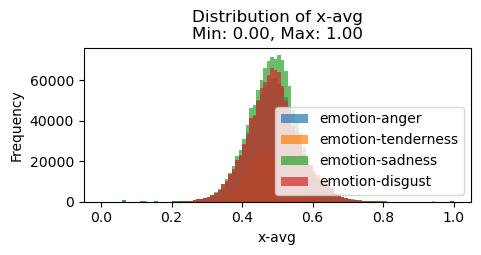

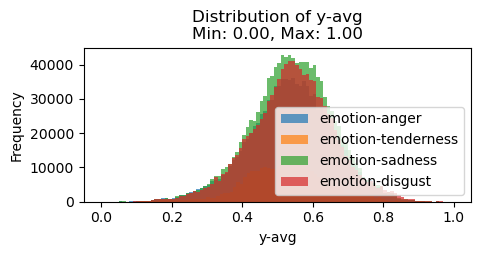

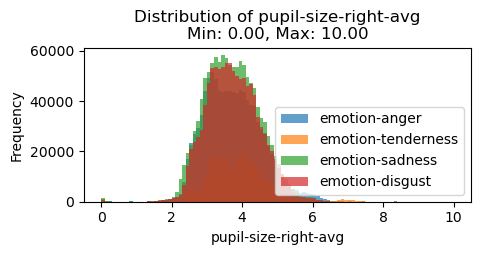

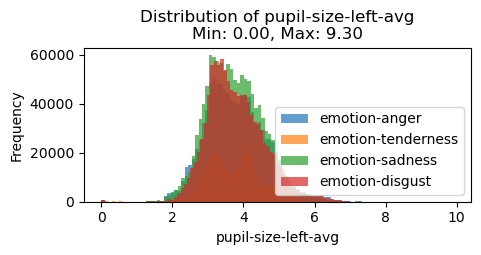

In [11]:
# plot distributions of raw signals per emotion
emotion_cols = [col for col in df.columns if "emotion" in col]
print(emotion_cols)
signals = ["x-avg", "y-avg", "pupil-size-right-avg", "pupil-size-left-avg"]
for signal in signals:
    for tresh in [5]:
        plt.figure(figsize=(5, 2))
        for emotion in emotion_cols:
            data = df.loc[df[emotion] > tresh, signal]
            min_val = data.min()
            max_val = data.max()

            # print(f"Distribution of {signal} for {emotion}:")
            # print(data.describe())
            # print("Percentage of NaN values: ",data.isna().sum()/len(data)*100)
        
            plt.hist(data, bins=100, alpha=0.7, label=emotion)
        plt.title(f"Distribution of {signal}\nMin: {min_val:.2f}, Max: {max_val:.2f}")
        plt.xlabel(signal)
        plt.ylabel("Frequency")
        plt.legend(loc='lower right')
        plt.show()


## Scatter plots: points on screen 
### Colored by emotion

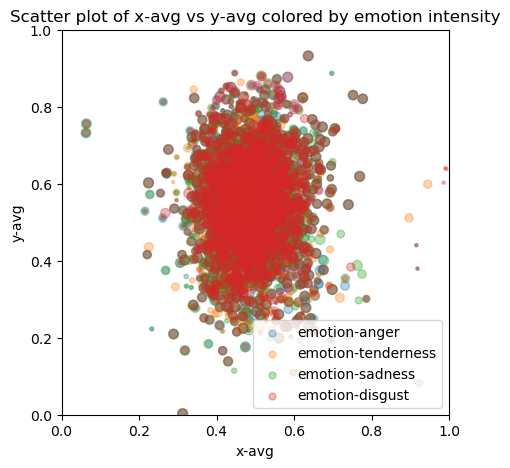

In [12]:
# scatter plot: each emotion is its own color, size according to intensity, x,y coordinates determined by "x-avg" and "y-avg"
emotion_cols = [col for col in df.columns if "emotion" in col]
# random sample to speed up plotting
df_temp = df.sample(n=5000, random_state=111)
plt.figure(figsize=(5, 5))
for emotion in emotion_cols:
    plt.scatter(df_temp["x-avg"], df_temp["y-avg"], s=df_temp[emotion]*5, alpha=0.33, label=emotion)
plt.title(f"Scatter plot of x-avg vs y-avg colored by emotion intensity")
plt.xlabel("x-avg")
plt.ylabel("y-avg")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

## Plot average emotion value for pupil size bins for all emotions



emotion-anger:
Count per bin: [  20447  480735 1620868  999016  203220   37398    1206]

emotion-tenderness:
Count per bin: [  20447  480735 1620868  999016  203220   37398    1206]

emotion-sadness:
Count per bin: [  20447  480735 1620868  999016  203220   37398    1206]

emotion-disgust:
Count per bin: [  20447  480735 1620868  999016  203220   37398    1206]


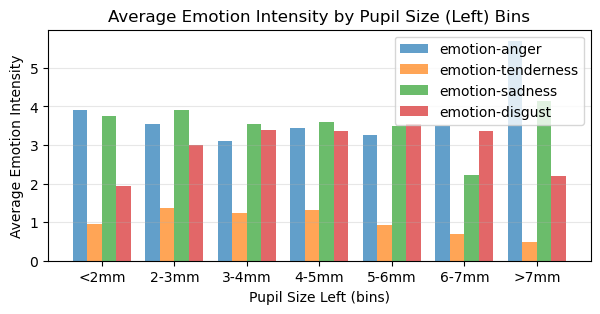

In [13]:
# plot average emotion value for pupil size bins for all emotions
# with shifted centers (side by side)

# Define pupil size bins
pupil_bins = [0, 2, 3, 4, 5, 6, 7, 10]
pupil_labels = ['<2mm', '2-3mm', '3-4mm', '4-5mm', '5-6mm', '6-7mm', '>7mm']

emotion_cols = [col for col in df.columns if "emotion" in col]

plt.figure(figsize=(7, 3))

bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars
x_positions = np.arange(len(pupil_labels))

for idx, emotion in enumerate(emotion_cols):
    # Create a copy of the data with non-null values
    df_temp = df[['pupil-size-left-avg', emotion]].dropna()
    
    # Create bins
    df_temp['pupil_bin'] = pd.cut(df_temp['pupil-size-left-avg'], bins=pupil_bins, labels=pupil_labels, include_lowest=True)
    
    # Calculate average emotion for each bin
    avg_emotion_per_bin = df_temp.groupby('pupil_bin',observed=False)[emotion].mean()
    count_per_bin = df_temp.groupby('pupil_bin',observed=False).size()
    
    print(f"\n{emotion}:")
    # print(f"Average per bin: {avg_emotion_per_bin.values}")
    print(f"Count per bin: {count_per_bin.values}")
    
    # Shift bin centers for each emotion
    shifted_positions = x_positions + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot bars
    plt.bar(shifted_positions, avg_emotion_per_bin.values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions, pupil_labels)
plt.xlabel('Pupil Size Left (bins)')
plt.ylabel('Average Emotion Intensity')
plt.title('Average Emotion Intensity by Pupil Size (Left) Bins')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


## Plot average pupil size for each emotion intensity value



emotion-anger:
Count per emotion value: [1445562  225637  250231  107711  124001  179507  102999  240629  171834
  195760  319019]

emotion-tenderness:
Count per emotion value: [2456147  118045  129802  113611   75745  133709   56615  144838   79841
   33162   21375]

emotion-sadness:
Count per emotion value: [1428175  195901  171430   93332  112762  151221  135395  269970  218162
  247233  339309]

emotion-disgust:
Count per emotion value: [1646332  134104  125398  140781   98420  134303   59443  205791  215178
  227473  375667]


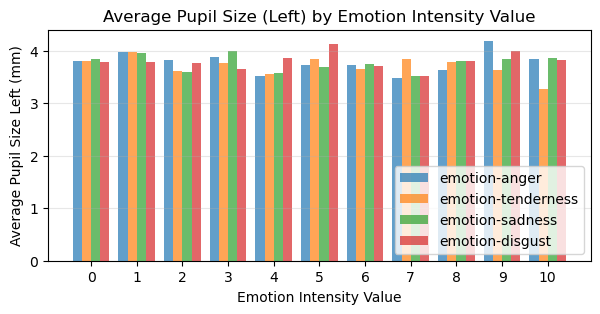

In [14]:
# plot average pupil size for each emotion intensity value
# emotion values are discrete 0-10, plot average pupil size for each emotion value

emotion_cols = [col for col in df.columns if "emotion" in col]

plt.figure(figsize=(7, 3))

bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars
emotion_values = np.arange(0, 11)  # 0 to 10

for idx, emotion in enumerate(emotion_cols):
    # Create a copy of the data with non-null values
    df_temp = df[['pupil-size-left-avg', emotion]].dropna()
    
    # Round emotion values to integers (in case they're floats)
    df_temp[emotion] = df_temp[emotion].round().astype(int)
    
    # Calculate average pupil size for each emotion value
    avg_pupil_per_emotion = df_temp.groupby(emotion)['pupil-size-left-avg'].mean()
    count_per_emotion = df_temp.groupby(emotion).size()
    
    print(f"\n{emotion}:")
    print(f"Count per emotion value: {count_per_emotion.values}")
    
    # Reindex to include all emotion values 0-10, fill missing with NaN
    avg_pupil_per_emotion = avg_pupil_per_emotion.reindex(emotion_values)
    
    # Shift bin centers for each emotion
    shifted_positions = emotion_values + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot bars (only where we have data)
    plt.bar(shifted_positions, avg_pupil_per_emotion.values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(emotion_values)
plt.xlabel('Emotion Intensity Value')
plt.ylabel('Average Pupil Size Left (mm)')
plt.title('Average Pupil Size (Left) by Emotion Intensity Value')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()


## Emotion distributions

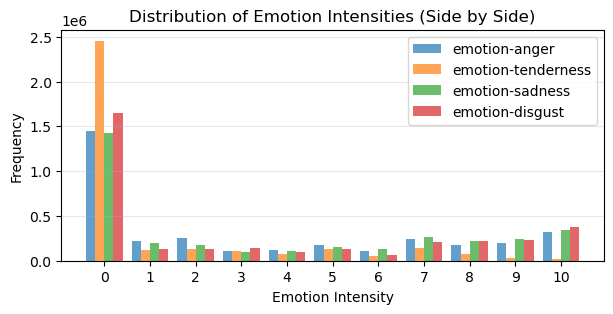

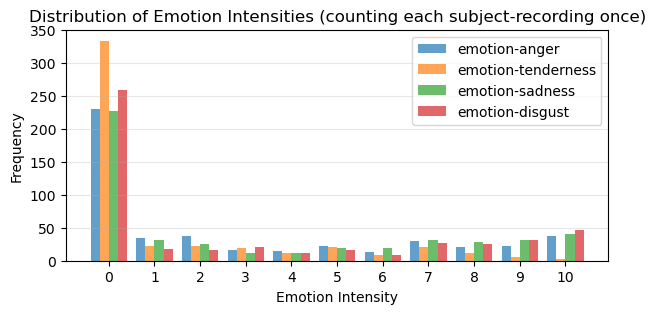

In [15]:
# =========================================================================
# plot emotion distributions
# =========================================================================
exclude_zero = 0

emotion_cols = [col for col in df.columns if "emotion" in col]
plt.figure(figsize=(7, 3))
# Define discrete bins for emotion values (1-10)
bins = np.arange(-0.5+exclude_zero, 11.5, 1)  # Creates bins centered at 1, 2, ..., 10
bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars

for idx, emotion in enumerate(emotion_cols):
    data = df[emotion].dropna()
    min_val = data.min()
    max_val = data.max()
    
    # Calculate histogram
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # Shift bin centers for each emotion
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot as bar chart
    plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
    
    # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

plt.title(f"Distribution of Emotion Intensities (Side by Side)")
plt.xlabel("Emotion Intensity")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.xticks(range(0+exclude_zero, 11))
plt.show()

# =========================================================================
# count each (subject, recording) pair once
# =========================================================================


# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

plt.figure(figsize=(7, 3))
bins = np.arange(-0.5 + exclude_zero, 11.5, 1)  # bins centered at 1..10 (or 0..10 if exclude_zero=0)
bar_width = 0.8 / len(emotion_cols)

for idx, emotion in enumerate(emotion_cols):
    data = df_sr[emotion].dropna()
    min_val, max_val = data.min(), data.max()

    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width

    plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
    # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

plt.title("Distribution of Emotion Intensities (counting each subject-recording once)")
plt.xlabel("Emotion Intensity")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.xticks(range(0 + exclude_zero, 11))
plt.show()

### Emotion distr. for each subject separately
Warning: 48 plots.

In [16]:
run_this_cell = False

if run_this_cell:
    # plot emotion distributions for each subject
    exclude_zero = 0

    emotion_cols = [col for col in df.columns if "emotion" in col]
    subjects = df['subject'].unique()

    for subject in subjects:
        plt.figure(figsize=(7, 4))
        
        # keep exactly one row per (subject, recording) so each pair is counted once
        df_temp = df[df['subject'] == subject]
        df_sr = df_temp.dropna().drop_duplicates(subset=["recording"])[["recording"] + emotion_cols]

        bins = np.arange(-0.5 + exclude_zero, 11.5, 1)  # bins centered at 1..10 (or 0..10 if exclude_zero=0)
        bar_width = 0.8 / len(emotion_cols)

        for idx, emotion in enumerate(emotion_cols):
            data = df_sr[emotion].dropna()
            min_val, max_val = data.min(), data.max()

            counts, bin_edges = np.histogram(data, bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width

            plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
            # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

        plt.title("Distribution of Emotion Intensities (counting each subject-recording once)")
        plt.xlabel("Emotion Intensity")
        plt.ylabel("Frequency")
        plt.grid(axis="y", alpha=0.3)
        plt.legend()
        plt.xticks(range(0 + exclude_zero, 11))
        plt.show()

### Average emotion intensity by recording

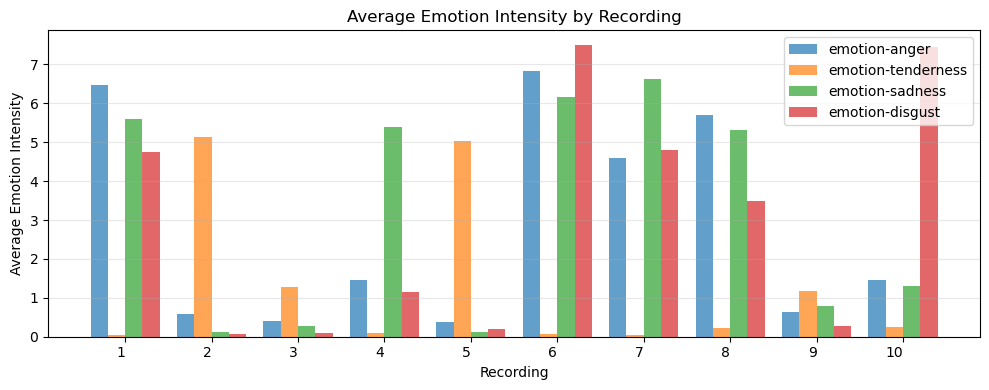

In [17]:
# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

# calculate average emotion intensity per recording
recordings = df_sr["recording"].unique()
recordings.sort()
avg_intensity_per_recording = {}

for emotion in emotion_cols:
    avg_intensity_per_recording[emotion] = df_sr.groupby("recording")[emotion].mean()

# plot
plt.figure(figsize=(10, 4))
bar_width = 0.8 / len(emotion_cols)
x_positions = np.arange(len(recordings))

for idx, emotion in enumerate(emotion_cols):
    avg_values = [avg_intensity_per_recording[emotion].get(rec, 0) for rec in recordings]
    shifted_positions = x_positions + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    plt.bar(shifted_positions, avg_values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions, recordings, ha='right')
plt.xlabel("Recording")
plt.ylabel("Average Emotion Intensity")
plt.title("Average Emotion Intensity by Recording")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Intended emotions by recording
| Index | Movie | Duration | Emotion |
|---- | ----| ----| ----|   
|1 | American history X | 1.17 | Anger| 
|2 | Benny and Joon | 2.01 | Tenderness| 
|3 | Blue (2) | 0.40 | Neutral| 
|4 | Ghost | 1.19 | Tenderness| 
|5 | Man bites dog (1) | 1.32 | Disgust| 
|6 | Schindler’s list (1) | 0.58 | Sadness| 
|7 | Schindler’s list (2) | 1.55 | Anger| 
|8 | The dreamlife of angels | 2.00 | Sadness| 
|9 | The lover | 0.43 | Neutral| 
|10 | Trainspotting (2) | 1.00 | Disgust| 

### Number of Subjects by Unique Emotion Intensities Reported 

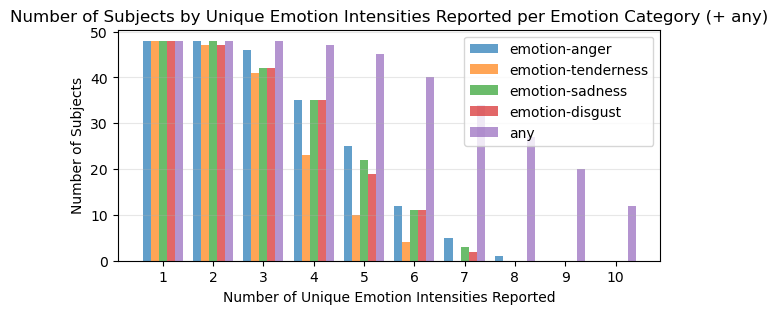

In [18]:

emotion_cols = [c for c in df.columns if "emotion" in c]
emo_plus_any = emotion_cols + ["any"]

subjects = df["subject"].unique()
max_unique_intensities = 10  # intensities 1..10
unique_intensity_counts = {e: np.zeros(max_unique_intensities, dtype=int) for e in emo_plus_any}

for subject in subjects:
    df_temp = df[df["subject"] == subject]

    # one row per recording for this subject (emotion constant per subject-recording)
    df_sr = df_temp.dropna(subset=["recording"]).drop_duplicates(subset=["recording"])[["recording"] + emotion_cols]

    # "any": total number of unique emotion values across all emotion columns & recordings for this subject
    # (values in 1..10; NaNs ignored)
    any_vals = pd.unique(df_sr[emotion_cols].to_numpy().ravel())
    any_vals = any_vals[~pd.isna(any_vals)]
    num_unique_any = len(any_vals)
    for i in range(min(num_unique_any, max_unique_intensities)):
        unique_intensity_counts["any"][i] += 1

    # per-emotion
    for emotion in emotion_cols:
        unique_intensities = df_sr[emotion].dropna().unique()
        num_unique = len(unique_intensities)
        for i in range(min(num_unique, max_unique_intensities)):
            unique_intensity_counts[emotion][i] += 1

# plot
plt.figure(figsize=(7, 3))
bar_width = 0.8 / len(emo_plus_any)
x_positions = np.arange(max_unique_intensities) + 1  # 1..10

for idx, emotion in enumerate(emo_plus_any):
    counts = unique_intensity_counts[emotion]
    shifted_positions = x_positions + (idx - len(emo_plus_any)/2 + 0.5) * bar_width
    plt.bar(shifted_positions, counts, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions)
plt.xlabel("Number of Unique Emotion Intensities Reported")
plt.ylabel("Number of Subjects")
plt.title("Number of Subjects by Unique Emotion Intensities Reported per Emotion Category (+ any)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## Number of subject-recording pairs with less than `thresh` distinct emotion intensity values

In [19]:
# how many subject, recording pairs have all emotions reported as <= thresh
# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

# check if all emotions are <= thresh for each (subject, recording) pair
thresh = 2
all_zero = (df_sr[emotion_cols] <= thresh).all(axis=1)

num_all_zero = all_zero.sum()
print(f"Number of subject-recording pairs with all emotions reported <= {thresh}: {num_all_zero}")
print(f"Subject-recording pairs with all emotions reported <= {thresh}:")
print(df_sr.loc[all_zero, ["subject", "recording"]])

Number of subject-recording pairs with all emotions reported <= 2: 116
Subject-recording pairs with all emotions reported <= 2:
         subject  recording
30101         17          9
43180         17          5
161027        16          6
206960         5         10
270957        34          3
...          ...        ...
3363103       24          9
3367432       37          3
3387353        2          9
3414761       43          9
3419051       27          3

[116 rows x 2 columns]


`df_sr` is subject-recording aggregated df

In [20]:
df = dfOG.copy() 
df_sr = df.dropna().groupby(["subject", "recording"]).mean(numeric_only=True).reset_index()


In [21]:
neutral_combinations = (df_sr[emotion_cols] == 0).all(axis=1).sum()
print(f"Number of netural subj-rec combinations: {neutral_combinations}. All combinations: {len(df_sr)}")

Number of netural subj-rec combinations: 48. All combinations: 480


## Outliers based on z-score of averages
### Outliers - Subject-recording paris 
- if score_l2 ~ score_max => then one metric dominates the outlier score, others are not contributing much

In [ ]:
def robust_z(x):
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0 or np.isnan(mad):
        return (x - med) * 0.0
    return 0.6745 * (x - med) / mad  # consistent w/ std for normal

def compute_outliers(df, cols):
    Z = df[cols].apply(robust_z, axis=0)
    df['outlier_score_l2'] = np.sqrt((Z**2).sum(axis=1))
    df['outlier_score_max'] = Z.abs().max(axis=1)

    # flag top outliers
    df = df.sort_values('outlier_score_l2', ascending=False)

    return df


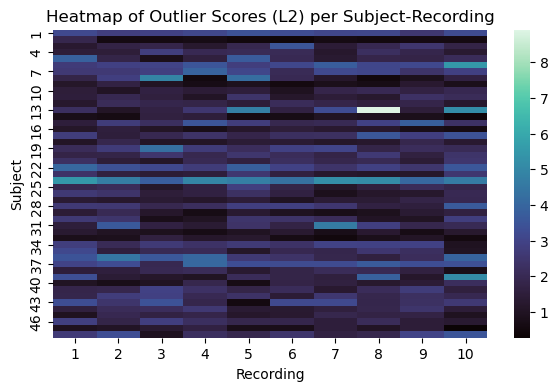

,subject,recording,outlier_score_l2,outlier_score_max,x-avg,y-avg,pupil-size-left-avg,pupil-size-right-avg
127,13,8,8.910394,8.615665,0.491891,0.589691,5.259911,10.373349
230,24,1,5.502093,3.436243,0.574709,0.352906,6.163324,5.917757
59,6,10,5.500964,5.015101,0.516751,0.404138,2.729762,7.635440
236,24,7,5.170077,3.606956,0.616432,0.431406,5.706337,5.401211
129,13,10,5.160402,4.788674,0.477005,0.554598,5.063401,7.463263
237,24,8,5.085856,3.841125,0.625011,0.349830,5.261751,4.730836


In [ ]:
# outliers based on signals 
signal_cols = ['x-avg', 'y-avg', 'pupil-size-left-avg', 'pupil-size-right-avg']
df_sr = compute_outliers(df_sr, signal_cols)

plt.figure(figsize=(7, 4))
sns.heatmap(df_sr.pivot(index='subject', columns='recording', values='outlier_score_l2'), cmap='mako')
plt.title('Heatmap of Signal Outlier Scores (L2) per Subject-Recording')
plt.xlabel('Recording')
plt.ylabel('Subject')
plt.show()

df_sr[['subject','recording','outlier_score_l2','outlier_score_max'] + signal_cols].head(6)

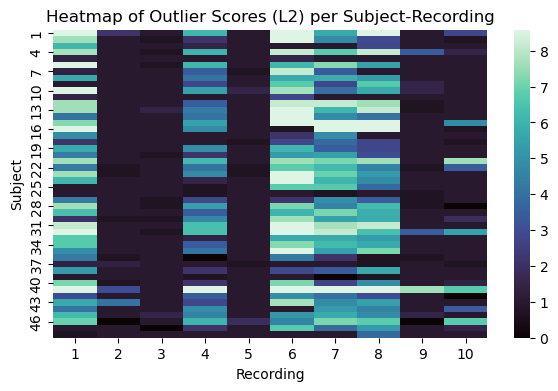

,subject,recording,outlier_score_l2,outlier_score_max,emotion-anger,emotion-tenderness,emotion-sadness,emotion-disgust
135,14,6,8.584983,6.0705,10.0,0.0,10.0,10.0
157,16,8,8.584983,6.0705,10.0,0.0,10.0,10.0
150,16,1,8.584983,6.0705,10.0,0.0,10.0,10.0
156,16,7,8.584983,6.0705,10.0,0.0,10.0,10.0
406,41,7,8.584983,6.0705,10.0,0.0,10.0,10.0
310,32,1,8.584983,6.0705,10.0,0.0,10.0,10.0


In [ ]:
# outliers based on emotions 
df_sr = compute_outliers(df_sr, emotion_cols)
plt.figure(figsize=(7, 4))
sns.heatmap(df_sr.pivot(index='subject', columns='recording', values='outlier_score_l2'), cmap='mako')
plt.title('Heatmap of Emotion Outlier Scores (L2) per Subject-Recording')
plt.xlabel('Recording')
plt.ylabel('Subject')
plt.show()

df_sr[['subject','recording','outlier_score_l2','outlier_score_max'] + emotion_cols].head(6)

### Outliers - Subjects

In [26]:
df_s = df.groupby("subject").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, signal_cols)
df_s[['subject','outlier_score_l2','outlier_score_max'] + signal_cols].head(6)

,subject,outlier_score_l2,outlier_score_max,x-avg,y-avg,pupil-size-left-avg,pupil-size-right-avg
23,24,4.628045,2.775203,0.564791,0.357114,5.775285,5.142754
36,37,3.475071,2.702096,0.399275,0.715700,4.217379,3.895883
21,22,3.332021,2.358662,0.410462,0.640261,4.873941,4.701159
12,13,3.146135,2.635470,0.482035,0.576172,4.944754,5.638466
6,7,3.009622,2.817237,0.579060,0.587638,3.199213,3.439911
35,36,2.940283,2.718061,0.453628,0.569927,3.878155,5.696354


In [27]:
df_s = df.groupby("subject").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, emotion_cols)
df_s[['subject','outlier_score_l2','outlier_score_max'] + emotion_cols].head(6)

,subject,outlier_score_l2,outlier_score_max,emotion-anger,emotion-tenderness,emotion-sadness,emotion-disgust
40,41,5.372435,3.671465,7.669952,0.959726,7.488514,7.670034
47,48,4.314552,2.364524,0.702911,0.198836,0.592745,0.000000
38,39,4.186295,2.535425,0.419753,0.382865,0.199171,0.755509
25,26,4.076574,2.844557,0.058660,1.193718,0.201539,0.825586
4,5,4.068994,2.204611,0.826871,0.000000,0.597857,1.026991
20,21,3.667226,2.495573,6.296406,1.785140,6.050721,6.294212


### Outliers - Recordings

In [28]:
df_s = df.groupby("recording").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, signal_cols)
df_s[['recording','outlier_score_l2','outlier_score_max'] + signal_cols].head(6)

,recording,outlier_score_l2,outlier_score_max,x-avg,y-avg,pupil-size-left-avg,pupil-size-right-avg
9,10,2.184248,1.622052,0.490488,0.539191,4.014303,4.290784
2,3,2.037897,1.743326,0.469752,0.531025,3.577057,3.691953
4,5,1.998572,1.205700,0.475272,0.536540,3.985615,4.163904
8,9,1.958726,1.273734,0.481829,0.555028,3.519462,3.546069
0,1,1.823576,1.603364,0.484443,0.529644,4.073365,4.048247
6,7,1.675697,1.133366,0.495314,0.552560,3.607465,3.720792


In [29]:
df_s = df.groupby("recording").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, emotion_cols)
df_s[['recording','outlier_score_l2','outlier_score_max'] + emotion_cols].head(6)

,recording,outlier_score_l2,outlier_score_max,emotion-anger,emotion-tenderness,emotion-sadness,emotion-disgust
1,2,16.715956,16.674045,0.579789,5.103022,0.122945,0.062234
4,5,16.414384,16.368746,0.376329,5.013967,0.124190,0.212583
5,6,3.809434,3.347738,6.804072,0.067435,6.114789,7.348665
2,3,3.782090,3.582612,0.400169,1.284266,0.273217,0.083265
8,9,3.437057,3.282324,0.631852,1.196672,0.791843,0.273179
0,1,3.223841,3.012743,6.269727,0.043491,5.519540,4.658459
